# Phase 1b — Nodal value with the scorer's **screening heuristic** (hourly, 2025)

Instead of the arbitrage LP, this values each nodal location with the **exact screening
heuristic the battery siting score uses** — `battery_siting_score/score_proxy.py`
(`daily_proxy`: `(mean top-k π − mean bottom-k π)·p̄·k·dt`, the single-cycle lossless
analytic answer to the daily LP). The only difference between the two sides of the
comparison is the **price signal**:

- siting score: redispatch-bent zonal intraday price π̂
- nodal value : PyPSA-Eur hourly nodal LMP

Same valuation operator ⇒ any ranking difference is due to the price signal, not the
method. Config matched to the scorer: **50 MW, 4 h**, `k = round(duration/dt)` steps per
half-cycle. Hourly only (`dt=1.0` ⇒ k = 4 and 24 steps/day); the 3-hourly 2013 run is
excluded on purpose (it can't resolve intraday spread).

The heuristic is a fast, lossless screen: it monetises one full charge/discharge cycle per
day (buy the k cheapest hours, sell the k dearest), so in absolute EUR it under-counts the
LP on multi-cycle days, but it preserves the locational **ranking**, which is all this
comparison uses.

In [1]:
%matplotlib inline
import importlib.util, sys, os, numpy as np, pandas as pd, netCDF4 as nc, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, kendalltau
plt.rcParams['figure.dpi']=110; plt.rcParams['font.size']=10
# import the scorer's EXACT screening heuristic (top-k / bottom-k proxy)
sys.path.insert(0, os.path.abspath('..'))
import battery_siting_score.score_proxy as PROXY
PMW,DUR=50.0,4.0                               # matches config.yaml
def heuristic_value(pi, p_bar=PMW, duration_hours=DUR, dt=1.0):
    """Scorer's screening heuristic summed over calendar days at the series' resolution.
    daily_proxy = (mean top-k - mean bottom-k) * p_bar * k * dt,  k = round(duration/dt)."""
    pi=np.asarray(pi,float); spd=int(round(24/dt)); k=int(round(duration_hours/dt))
    nd=len(pi)//spd
    return float(sum(PROXY.daily_proxy(pi[d*spd:(d+1)*spd], p_bar, k, dt=dt) for d in range(nd)))
SITE="../battery_siting_score/out/grid_siting_scores_20260629_155333.csv"
SCORE_COL="dV_proxy_eur_per_year"
SOLVED="../results/de-nodal-2025-hourly/networks/base_s_30_elec_.nc"
BASE_S="../resources/de-nodal-2025-hourly/networks/base_s.nc"
BUSMAP="../resources/de-nodal-2025-hourly/busmap_base_s_30.csv"
sit=pd.read_csv(SITE); _tree=cKDTree(sit[['lon','lat']].values)

## 1. Hourly nodal LMP → heuristic arbitrage value per DE node (scorer's engine)

In [2]:
ds=nc.Dataset(SOLVED)
rs=lambda n:(list(nc.chartostring(ds.variables[n][:])) if ds.variables[n][:].dtype.kind in 'SU' else ds.variables[n][:])
bus=[str(b) for b in rs('buses_i')]; ctry=[str(c) for c in rs('buses_country')]
mp=np.array(ds.variables['buses_t_marginal_price'][:]); mpi=[str(b) for b in rs('buses_t_marginal_price_i')]
ds.close()
if mp.shape[0]==len(mpi): mp=mp.T
price=pd.DataFrame(mp,columns=mpi); de=[b for b,c in zip(bus,ctry) if c=='DE']
rows=[]
for b in de:
    pi=price[b].values                                    # 8760 hourly LMPs
    v_heur = heuristic_value(pi)                          # <-- scorer's exact screening heuristic
    rows.append(dict(node=b, heur_value_eur_yr=v_heur,
                     mean_price=pi.mean(), spread_p95_p5=np.percentile(pi,95)-np.percentile(pi,5)))
nm=pd.DataFrame(rows)
nm['abs_congestion']=(nm.mean_price-nm.mean_price.mean()).abs()
nm.sort_values('heur_value_eur_yr',ascending=False).round(1)

,node,heur_value_eur_yr,mean_price,spread_p95_p5,abs_congestion
6,DE0 15AC,489017.3,25.4,20.8,1.5
12,DE0 5AC,450357.0,25.7,18.9,1.3
15,DE0 8AC,366228.4,26.2,15.5,0.8
11,DE0 4AC,359604.2,26.2,15.2,0.8
13,DE0 6AC,349090.9,26.4,15.3,0.6
0,DE0 0AC,348572.0,26.5,14.9,0.5
5,DE0 14AC,320814.4,26.9,13.8,0.0
14,DE0 7AC,307669.6,27.2,13.2,0.3
4,DE0 13AC,289059.1,27.4,13.1,0.4
2,DE0 11AC,271678.3,27.3,13.1,0.4


## 2. Exact busmap join + siting value per fine bus

In [3]:
ds=nc.Dataset(BASE_S)
rs=lambda n:(list(nc.chartostring(ds.variables[n][:])) if ds.variables[n][:].dtype.kind in 'SU' else ds.variables[n][:])
fb=pd.DataFrame({'name':[str(b) for b in rs('buses_i')],'x':rs('buses_x'),'y':rs('buses_y'),
                 'country':[str(c) for c in rs('buses_country')]}); ds.close()
fb=fb[fb.country=='DE'].merge(pd.read_csv(BUSMAP),on='name').merge(nm,left_on='busmap',right_on='node')
d,idx=_tree.query(fb[['x','y']].values,k=1)
fb['sit_dV']=sit[SCORE_COL].values[idx]; fb['snap_km']=d*111
node=(fb.groupby('busmap').agg(sit_dV=('sit_dV','mean'),n_buses=('name','size'),
        heur_value_eur_yr=('heur_value_eur_yr','first'),spread_p95_p5=('spread_p95_p5','first'),
        abs_congestion=('abs_congestion','first'),x=('x','mean'),y=('y','mean')).reset_index())
print(f"fine DE buses={len(fb)}  nodes={len(node)}  median snap {fb.snap_km.median():.1f} km")

fine DE buses=489  nodes=17  median snap 4.3 km


## 3. Rank agreement — siting score vs heuristic-based nodal value

In [4]:
def boot(x,y,n=3000,seed=0):
    rng=np.random.default_rng(seed); x=np.asarray(x); y=np.asarray(y); r=[]
    for _ in range(n):
        i=rng.integers(0,len(x),len(x)); r.append(spearmanr(x[i],y[i])[0])
    return np.nanpercentile(r,[2.5,97.5])
res=[]
for lab,xx,yy in [('node: siting vs heuristic value',node.sit_dV,node.heur_value_eur_yr),
                  ('node: siting vs price spread',node.sit_dV,node.spread_p95_p5),
                  ('node: siting vs |congestion| (old)',node.sit_dV,node.abs_congestion),
                  ('bus: siting vs heuristic value',fb.sit_dV,fb.heur_value_eur_yr)]:
    rho,p=spearmanr(xx,yy); tau,_=kendalltau(xx,yy); lo,hi=boot(xx,yy)
    res.append(dict(comparison=lab,n=len(xx),spearman=round(rho,3),kendall=round(tau,3),
                    ci95=f"[{lo:+.2f},{hi:+.2f}]",p=round(p,4)))
pd.DataFrame(res)

,comparison,n,spearman,kendall,ci95,p
0,node: siting vs heuristic value,17,0.647,0.426,"[+0.24,+0.85]",0.0050
1,node: siting vs price spread,17,0.598,0.382,"[+0.17,+0.81]",0.0112
2,node: siting vs |congestion| (old),17,-0.174,-0.103,"[-0.60,+0.34]",0.5041
3,bus: siting vs heuristic value,489,0.296,0.198,"[+0.22,+0.37]",0.0000


## 4. Value-capture curve (decision metric)

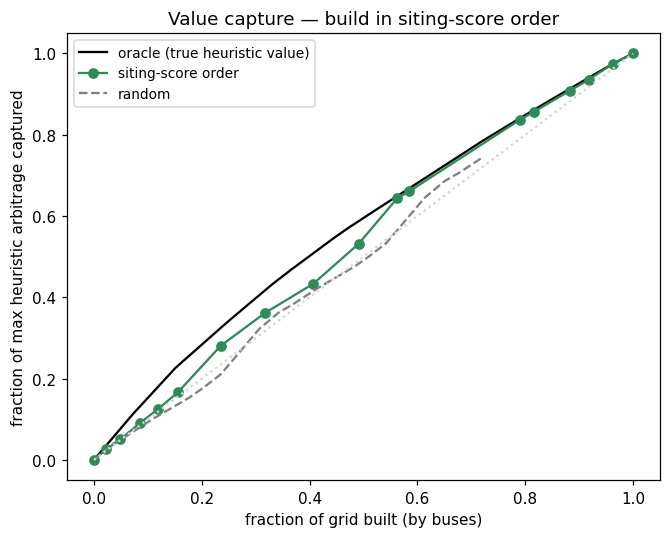

In [5]:
w=node['n_buses'].values; val=node['heur_value_eur_yr'].values
def cum(order): return np.cumsum(w[order])/w.sum(), np.cumsum((val*w)[order])/(val*w).sum()
fs,vs=cum(np.argsort(-node['sit_dV'].values)); fo,vo=cum(np.argsort(-val)); fr,vr=cum(node.index.values%7)
plt.figure(figsize=(6.2,5))
plt.plot(np.r_[0,fo],np.r_[0,vo],'k-',label='oracle (true heuristic value)')
plt.plot(np.r_[0,fs],np.r_[0,vs],'o-',color='seagreen',label='siting-score order')
plt.plot(np.r_[0,fr],np.r_[0,vr],'--',color='grey',label='random')
plt.plot([0,1],[0,1],':',color='lightgrey')
plt.xlabel('fraction of grid built (by buses)'); plt.ylabel('fraction of max heuristic arbitrage captured')
plt.title('Value capture — build in siting-score order'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

## 5. Scatter + save

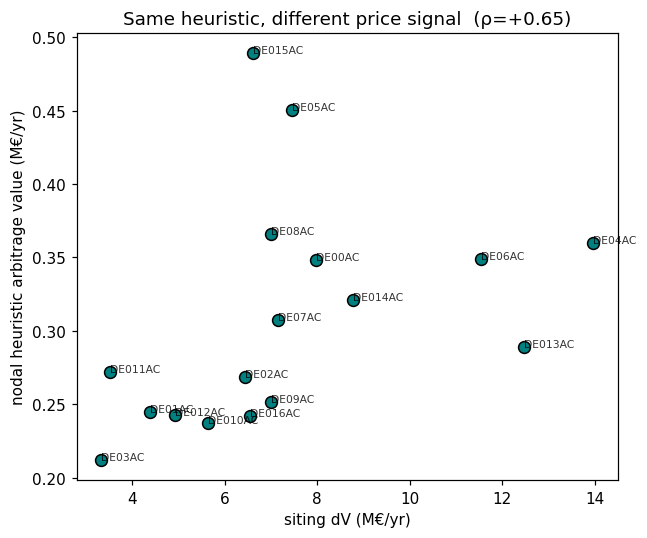

saved node + bus tables


In [6]:
plt.figure(figsize=(6,5))
plt.scatter(node.sit_dV/1e6,node.heur_value_eur_yr/1e6,s=60,c='teal',edgecolor='k')
for _,r in node.iterrows(): plt.annotate(r['busmap'].replace(' ',''),(r.sit_dV/1e6,r.heur_value_eur_yr/1e6),fontsize=7,alpha=.8)
rho,_=spearmanr(node.sit_dV,node.heur_value_eur_yr)
plt.xlabel('siting dV (M€/yr)'); plt.ylabel('nodal heuristic arbitrage value (M€/yr)')
plt.title(f'Same heuristic, different price signal  (ρ={rho:+.2f})'); plt.tight_layout(); plt.show()
node.to_csv("phase1b_LP_nodal_value_vs_siting_2025hourly.csv",index=False)
fb[['name','busmap','x','y','sit_dV','heur_value_eur_yr','snap_km']].to_csv("phase1b_LP_buswise_2025hourly.csv",index=False)
print("saved node + bus tables")

## 6. Diagnostic correlation matrix (node level, Spearman)

Quick orientation: which metrics move together. Note heuristic value tracks **spread**, not mean price or |congestion|.

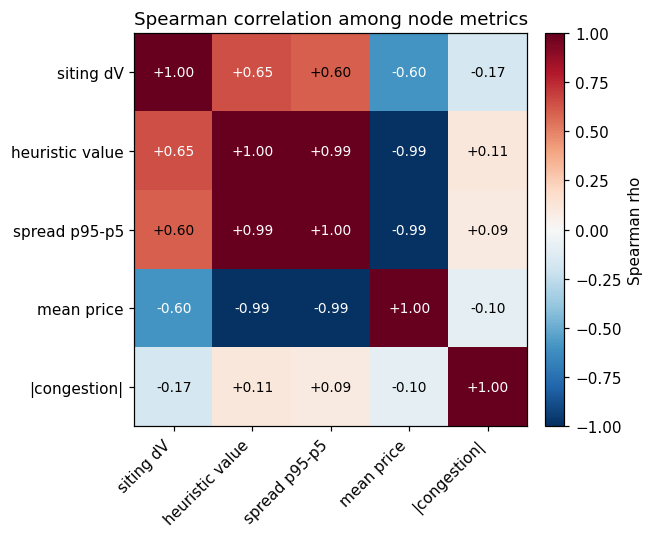

In [7]:
# node-level frame with mean_price merged back in
dfm = node.merge(nm[['node','mean_price']], left_on='busmap', right_on='node')
cols   = ['sit_dV','heur_value_eur_yr','spread_p95_p5','mean_price','abs_congestion']
labels = ['siting dV','heuristic value','spread p95-p5','mean price','|congestion|']
Cm = dfm[cols].corr(method='spearman').values
fig,ax = plt.subplots(figsize=(5.8,5))
im = ax.imshow(Cm, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
ax.set_xticklabels(labels, rotation=45, ha='right'); ax.set_yticklabels(labels)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j,i,f"{Cm[i,j]:+.2f}",ha='center',va='center',
                color='white' if abs(Cm[i,j])>0.6 else 'black',fontsize=9)
fig.colorbar(im,fraction=0.046,pad=0.04,label='Spearman rho')
ax.set_title('Spearman correlation among node metrics'); plt.tight_layout(); plt.show()

## 7. What drives heuristic arbitrage value?

heuristic value vs the three candidate signals. Spread is the near-linear driver; price level and the old |congestion| proxy are not.

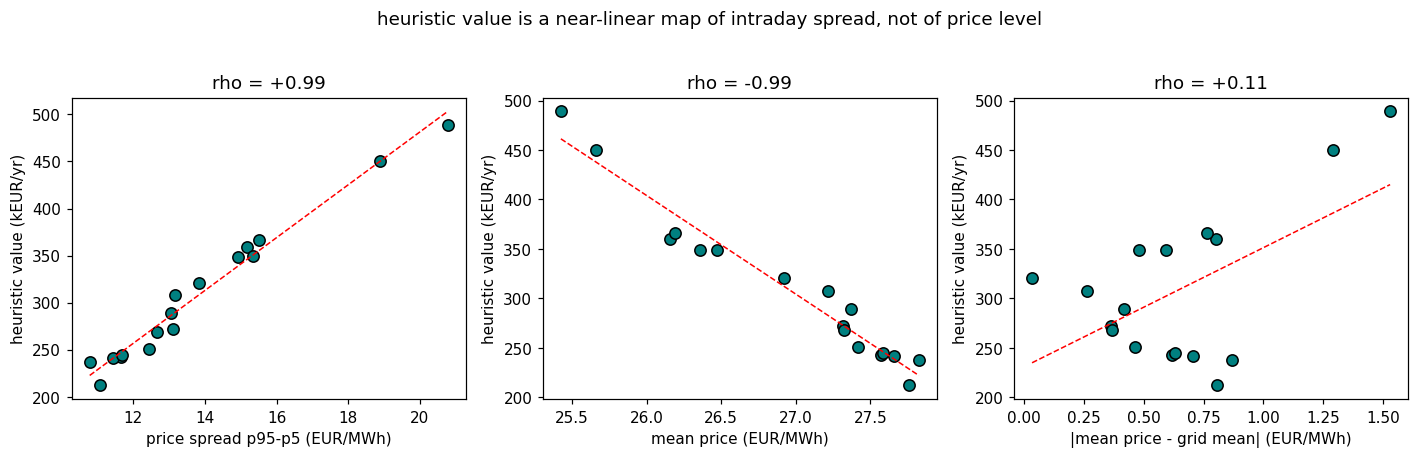

In [8]:
fig,axs = plt.subplots(1,3,figsize=(13,4))
for ax,(col,name) in zip(axs,[('spread_p95_p5','price spread p95-p5 (EUR/MWh)'),
                              ('mean_price','mean price (EUR/MWh)'),
                              ('abs_congestion','|mean price - grid mean| (EUR/MWh)')]):
    x = dfm[col].values; y = dfm['heur_value_eur_yr'].values/1e3
    ax.scatter(x,y,s=55,c='teal',edgecolor='k')
    b,a = np.polyfit(x,y,1); xs = np.linspace(x.min(),x.max(),50)
    ax.plot(xs,a+b*xs,'r--',lw=1)
    rho,_ = spearmanr(x,y)
    ax.set_xlabel(name); ax.set_ylabel('heuristic value (kEUR/yr)'); ax.set_title(f'rho = {rho:+.2f}')
fig.suptitle('heuristic value is a near-linear map of intraday spread, not of price level', y=1.03)
plt.tight_layout(); plt.show()

## 8. Rank-rank agreement (which nodes agree / disagree)

Perfect agreement lies on the diagonal. Colour = size of the rank disagreement; the printed table lists the worst offenders.

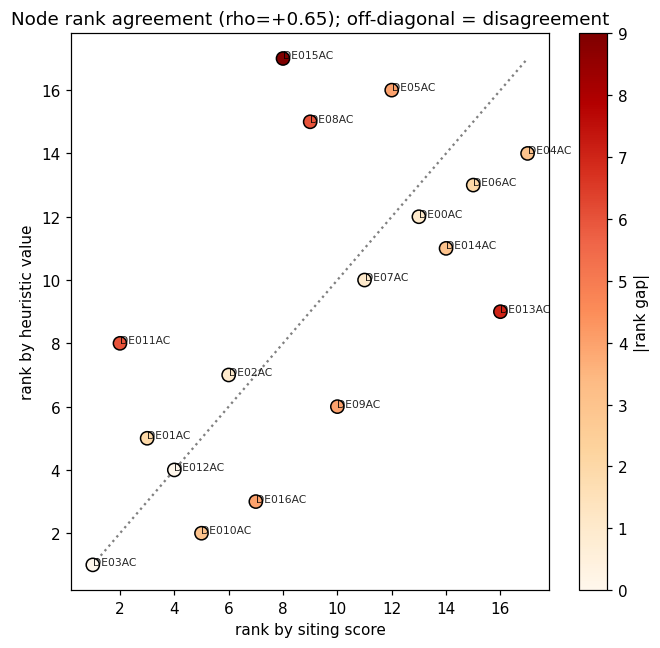

Largest rank disagreements:
  busmap  rank_sit  rank_lp  rank_gap
DE0 15AC       8.0     17.0       9.0
DE0 13AC      16.0      9.0       7.0
DE0 11AC       2.0      8.0       6.0
 DE0 8AC       9.0     15.0       6.0
 DE0 5AC      12.0     16.0       4.0


In [9]:
r_sit = pd.Series(dfm['sit_dV'].values).rank().values
r_lp  = pd.Series(dfm['heur_value_eur_yr'].values).rank().values
dfm2  = dfm.assign(rank_sit=r_sit, rank_lp=r_lp, rank_gap=np.abs(r_sit-r_lp))
plt.figure(figsize=(6.2,6))
plt.plot([1,len(dfm2)],[1,len(dfm2)],':',color='grey')
sc = plt.scatter(r_sit,r_lp,s=75,c=dfm2['rank_gap'],cmap='OrRd',edgecolor='k',zorder=3)
for _,r in dfm2.iterrows():
    plt.annotate(r['busmap'].replace(' ',''),(r['rank_sit'],r['rank_lp']),fontsize=7,alpha=.85)
plt.colorbar(sc,label='|rank gap|'); plt.xlabel('rank by siting score'); plt.ylabel('rank by heuristic value')
rho,_ = spearmanr(r_sit,r_lp)
plt.title(f'Node rank agreement (rho={rho:+.2f}); off-diagonal = disagreement')
plt.tight_layout(); plt.show()
print("Largest rank disagreements:")
print(dfm2.sort_values('rank_gap',ascending=False)[['busmap','rank_sit','rank_lp','rank_gap']].head(5).to_string(index=False))

## 9. How solid is the rho? Bootstrap + leave-one-out

With only 17 nodes the point estimate is fragile. Left: bootstrap distribution and 95% CI. Right: rho recomputed dropping each node in turn.

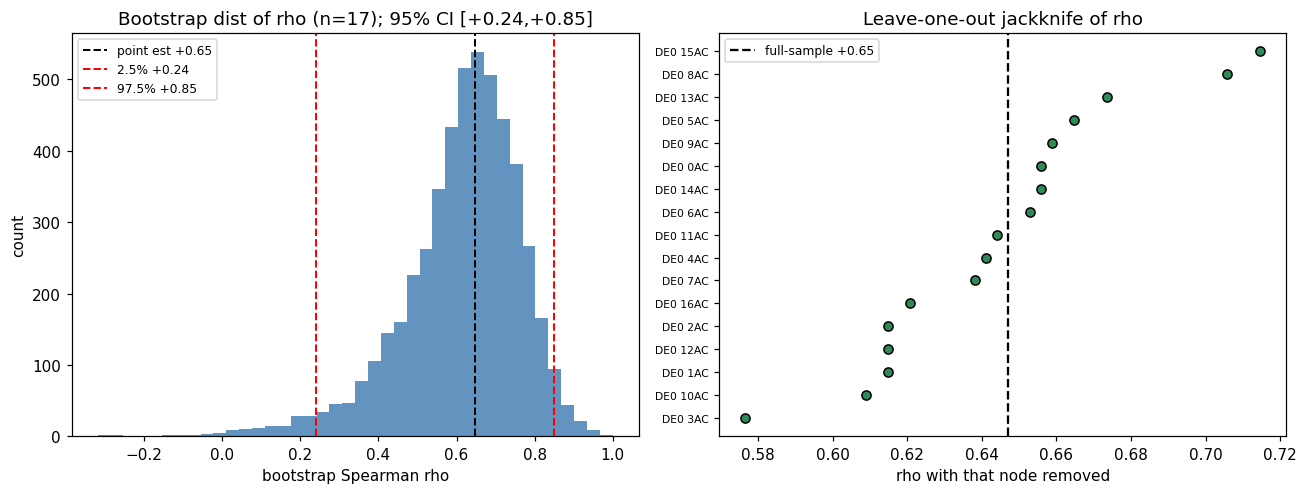

jackknife rho range: +0.58 ... +0.71  (full sample +0.65)


In [10]:
xx = dfm['sit_dV'].values; yy = dfm['heur_value_eur_yr'].values
rng = np.random.default_rng(0); reps = []
for _ in range(5000):
    i = rng.integers(0,len(xx),len(xx)); reps.append(spearmanr(xx[i],yy[i])[0])
reps = np.array(reps); lo,hi = np.nanpercentile(reps,[2.5,97.5]); pt = spearmanr(xx,yy)[0]
jk = [spearmanr(np.delete(xx,k),np.delete(yy,k))[0] for k in range(len(xx))]
fig,axs = plt.subplots(1,2,figsize=(12,4.6))
axs[0].hist(reps,bins=40,color='steelblue',alpha=.85)
for v,c,l in [(pt,'k','point est'),(lo,'r','2.5%'),(hi,'r','97.5%')]:
    axs[0].axvline(v,color=c,ls='--',lw=1.3,label=f'{l} {v:+.2f}')
axs[0].set_xlabel('bootstrap Spearman rho'); axs[0].set_ylabel('count')
axs[0].set_title(f'Bootstrap dist of rho (n={len(xx)}); 95% CI [{lo:+.2f},{hi:+.2f}]'); axs[0].legend(fontsize=8)
order = np.argsort(jk)
axs[1].scatter(np.array(jk)[order],range(len(jk)),c='seagreen',edgecolor='k',zorder=3)
axs[1].axvline(pt,color='k',ls='--',label=f'full-sample {pt:+.2f}')
axs[1].set_yticks(range(len(jk))); axs[1].set_yticklabels(dfm['busmap'].values[order],fontsize=7)
axs[1].set_xlabel('rho with that node removed'); axs[1].set_title('Leave-one-out jackknife of rho'); axs[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"jackknife rho range: {min(jk):+.2f} ... {max(jk):+.2f}  (full sample {pt:+.2f})")

## 10. Node-count sensitivity (does agreement converge as the benchmark refines?)

Recomputes the siting-vs-heuristic Spearman for the 20- and 30-node solves. Only these two solved LMP networks exist, so this is a 2-point trend, not a full sweep.

clustering  n_de_nodes  rho_node  rho_bus
 base_s_20          10     0.479    0.219
 base_s_30          17     0.647    0.296


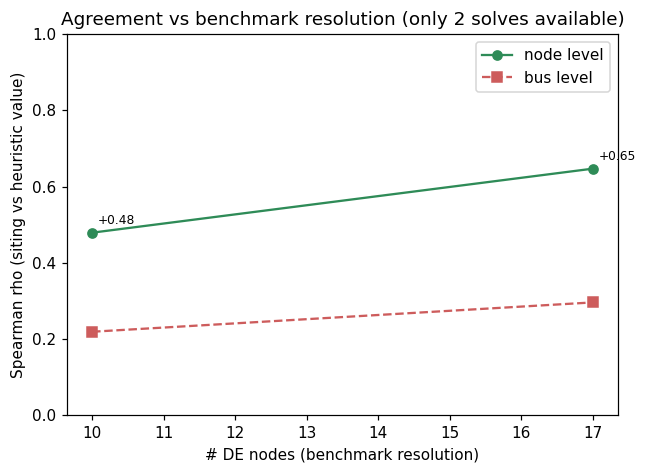

In [11]:
# 20-node point is precomputed to cache_sweep20_*.csv (see precompute.py) to keep this
# notebook fast to run; the 30-node point reuses `node`/`fb` computed above.
n20=pd.read_csv('cache_sweep20_node.csv'); f20=pd.read_csv('cache_sweep20_bus.csv')
sw=[dict(clustering='base_s_20', n_de_nodes=len(n20),
         rho_node=round(spearmanr(n20.sit_dV,n20.heur_value_eur_yr)[0],3),
         rho_bus =round(spearmanr(f20.sit_dV,f20.heur_value_eur_yr)[0],3)),
    dict(clustering='base_s_30', n_de_nodes=len(node),
         rho_node=round(spearmanr(node.sit_dV,node.heur_value_eur_yr)[0],3),
         rho_bus =round(spearmanr(fb.sit_dV,fb.heur_value_eur_yr)[0],3))]
swdf=pd.DataFrame(sw); print(swdf.to_string(index=False))
plt.figure(figsize=(6,4.4))
plt.plot(swdf.n_de_nodes,swdf.rho_node,'o-',color='seagreen',label='node level')
plt.plot(swdf.n_de_nodes,swdf.rho_bus,'s--',color='indianred',label='bus level')
for _,r in swdf.iterrows(): plt.annotate(f"{r.rho_node:+.2f}",(r.n_de_nodes,r.rho_node),textcoords='offset points',xytext=(4,6),fontsize=8)
plt.xlabel('# DE nodes (benchmark resolution)'); plt.ylabel('Spearman rho (siting vs heuristic value)')
plt.title('Agreement vs benchmark resolution (only 2 solves available)'); plt.ylim(0,1); plt.legend(); plt.tight_layout(); plt.show()

## 11. Efficiency sensitivity (lossless vs lossy heuristic, η_rt=0.85)

The screening heuristic is lossless by construction (it assumes everything charged is sold
back). Here we re-value every node with the natural lossy extension of the **same** heuristic,
`(η_rt·top − bottom)·p̄·k·dt` with η_rt=0.85, and check whether the ranking (and the
siting agreement) survives the lossless assumption.

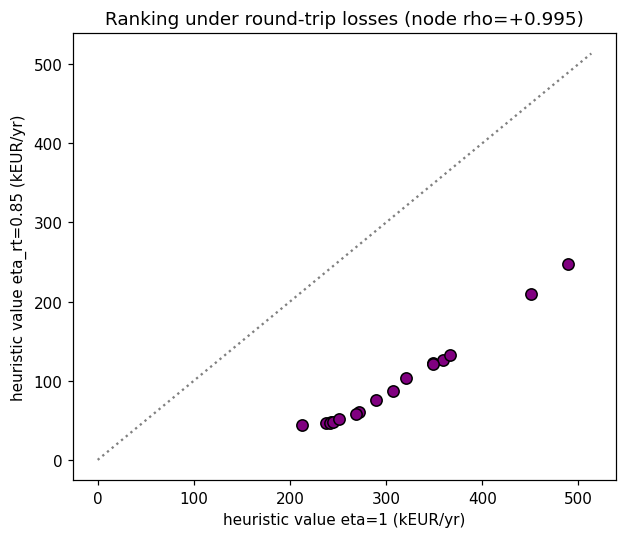

siting-vs-heuristic Spearman:  η=1 +0.647   η_rt=0.85 +0.645
mean value drop under losses: 69.0%


In [12]:
# 30-node revaluation with the lossy heuristic (eta_rt=0.85) is precomputed to cache_eta085_node.csv
node085=pd.read_csv('cache_eta085_node.csv')
m=node.merge(node085[['busmap','heur_value_eur_yr']],on='busmap',suffixes=('_eta1','_eta085'))
plt.figure(figsize=(5.8,5))
plt.scatter(m.heur_value_eur_yr_eta1/1e3,m.heur_value_eur_yr_eta085/1e3,s=55,c='purple',edgecolor='k')
hi=m.heur_value_eur_yr_eta1.max()/1e3*1.05
plt.plot([0,hi],[0,hi],':',color='grey')
plt.xlabel('heuristic value eta=1 (kEUR/yr)'); plt.ylabel('heuristic value eta_rt=0.85 (kEUR/yr)')
rho_e=spearmanr(m.heur_value_eur_yr_eta1,m.heur_value_eur_yr_eta085)[0]
plt.title(f'Ranking under round-trip losses (node rho={rho_e:+.3f})'); plt.tight_layout(); plt.show()
r1  =spearmanr(node.sit_dV,node.heur_value_eur_yr)[0]
r085=spearmanr(node085.sit_dV,node085.heur_value_eur_yr)[0]
print(f"siting-vs-heuristic Spearman:  η=1 {r1:+.3f}   η_rt=0.85 {r085:+.3f}")
print(f"mean value drop under losses: {(1-m.heur_value_eur_yr_eta085.sum()/m.heur_value_eur_yr_eta1.sum())*100:.1f}%")

## 12. Spatial view - value vs siting across Germany

DE nodes by benchmark heuristic value, by siting score, and by their rank disagreement (red = siting over-ranks vs heuristic; blue = under-ranks).

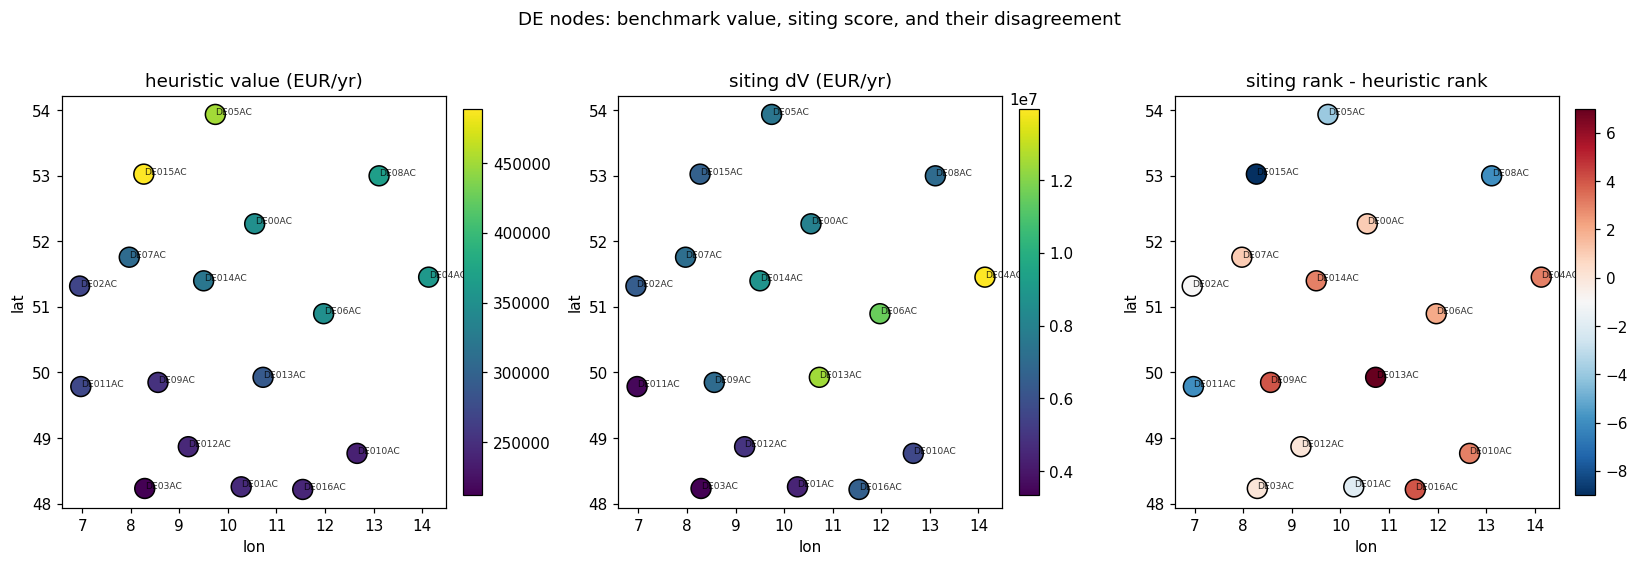

In [13]:
mm = node.merge(nm[['node','mean_price']],left_on='busmap',right_on='node')
mm['rank_gap'] = pd.Series(mm['sit_dV']).rank().values - pd.Series(mm['heur_value_eur_yr']).rank().values
fig,axs = plt.subplots(1,3,figsize=(15,5))
panels=[('heur_value_eur_yr','heuristic value (EUR/yr)','viridis'),
        ('sit_dV','siting dV (EUR/yr)','viridis'),
        ('rank_gap','siting rank - heuristic rank','RdBu_r')]
for ax,(col,name,cmap) in zip(axs,panels):
    sc=ax.scatter(mm.x,mm.y,c=mm[col],s=170,cmap=cmap,edgecolor='k')
    for _,r in mm.iterrows(): ax.annotate(r['busmap'].replace(' ',''),(r.x,r.y),fontsize=6,alpha=.8)
    fig.colorbar(sc,ax=ax,fraction=0.046,pad=0.04); ax.set_title(name); ax.set_xlabel('lon'); ax.set_ylabel('lat')
fig.suptitle('DE nodes: benchmark value, siting score, and their disagreement', y=1.02)
plt.tight_layout(); plt.show()

## 13. Where does arbitrage value come from? Price duration curves

Sorted hourly LMPs for the highest- and lowest-value nodes. The vertical gap between the dotted p5/p95 lines is the arbitrage the heuristic monetises.

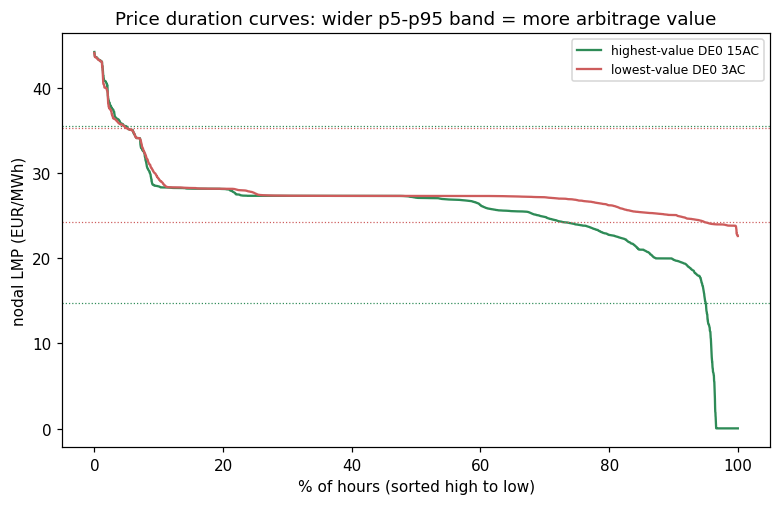

In [14]:
hi_n = nm.sort_values('heur_value_eur_yr').iloc[-1]['node']
lo_n = nm.sort_values('heur_value_eur_yr').iloc[0]['node']
plt.figure(figsize=(7.2,4.7))
for b,c,l in [(hi_n,'seagreen','highest-value '+hi_n),(lo_n,'indianred','lowest-value '+lo_n)]:
    pv=np.sort(price[b].values)[::-1]
    plt.plot(np.linspace(0,100,len(pv)),pv,color=c,label=l)
    p5,p95=np.percentile(price[b].values,[5,95])
    plt.axhline(p95,color=c,ls=':',lw=.8); plt.axhline(p5,color=c,ls=':',lw=.8)
plt.xlabel('% of hours (sorted high to low)'); plt.ylabel('nodal LMP (EUR/MWh)')
plt.title('Price duration curves: wider p5-p95 band = more arbitrage value'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 14. The benchmark blind spot - siting varies within a node, heuristic value does not

Each box is the spread of bus-level siting scores inside one node region; the red diamond is that node's single heuristic value. This is why the bus-level Spearman collapses: the nodal benchmark has no within-node resolution.

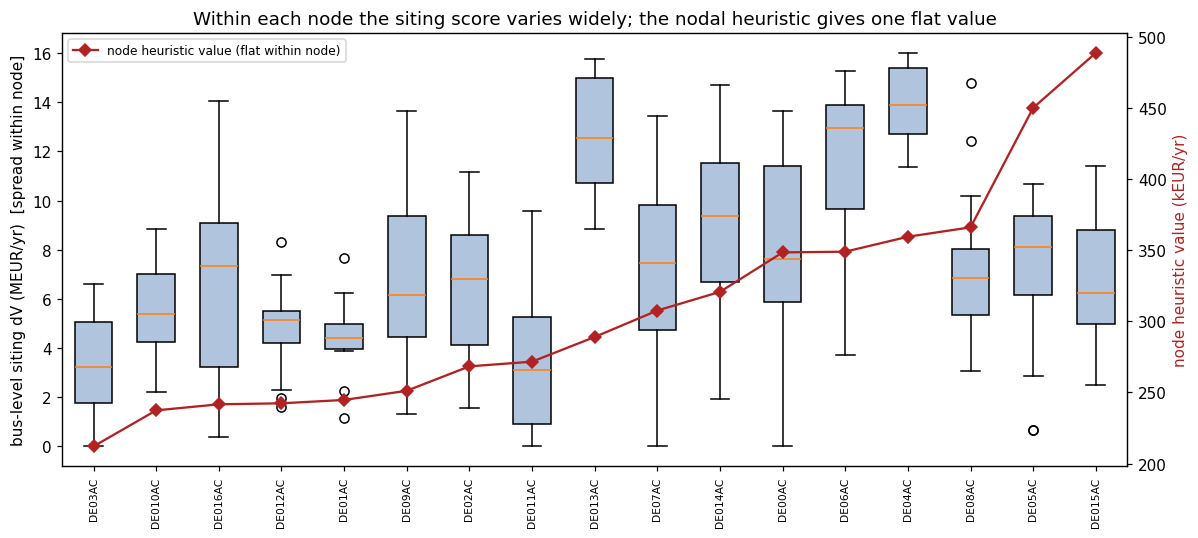

In [15]:
order = node.sort_values('heur_value_eur_yr')['busmap'].tolist()
data  = [fb[fb.busmap==b]['sit_dV'].values/1e6 for b in order]
fig,ax = plt.subplots(figsize=(11,5))
bp = ax.boxplot(data,vert=True,patch_artist=True,widths=.6)
for patch in bp['boxes']: patch.set_facecolor('lightsteelblue')
lpv = [node[node.busmap==b]['heur_value_eur_yr'].values[0]/1e3 for b in order]
ax2 = ax.twinx(); ax2.plot(range(1,len(order)+1),lpv,'D-',color='firebrick',label='node heuristic value (flat within node)')
ax.set_xticks(range(1,len(order)+1)); ax.set_xticklabels([b.replace(' ','') for b in order],rotation=90,fontsize=7)
ax.set_ylabel('bus-level siting dV (MEUR/yr)  [spread within node]')
ax2.set_ylabel('node heuristic value (kEUR/yr)',color='firebrick')
ax.set_title('Within each node the siting score varies widely; the nodal heuristic gives one flat value')
ax2.legend(loc='upper left',fontsize=8); plt.tight_layout(); plt.show()

## 15. Takeaway

- Both sides now use the identical price-taker screening heuristic (`score_proxy.daily_proxy`), so this is
  the cleanest possible test: only the **price signal** differs.
- Read the §3 Spearman (siting vs heuristic value) with its bootstrap CI as the headline; §4 is
  the decision-relevant value-capture statement.
- Caveats to keep: 17 solved German nodes (validates node-region ranking, not within-node
  siting), single weather year (2025), hourly LMP resolution.